Tested with following versions:



*   Python 3.11.13
*   pandas version: 2.2.2
*   matplotlib version: 3.10.0
*   scikit-learn version: 1.6.1
*   numpy version: 2.0.2

In [52]:
# Import relevant packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [53]:
# Import data from dropbox
!wget -O FRED-monthly-2025-07.csv https://www.dropbox.com/scl/fi/qqw8frg6y7m84y2kn9n34/FRED-monthly-2025-07.csv?rlkey=d7nhg4s30eeh08e9rw0r6775g&dl=0

# Import
fred = pd.read_csv("FRED-monthly-2025-07.csv", encoding='latin1')
print(fred.head())

--2025-08-15 19:15:03--  https://www.dropbox.com/scl/fi/qqw8frg6y7m84y2kn9n34/FRED-monthly-2025-07.csv?rlkey=d7nhg4s30eeh08e9rw0r6775g
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc14c38e550c8555baf933879aff.dl.dropboxusercontent.com/cd/0/inline/CvdOddONFWk49bc8ZhtpcMyZ5lM6q18cgwwSjucs8FokvgjLFIl7y_3qoVkB3IJ9WBZ2V-TggeIr5ev_um4l-SBlROTqWl7CD00bfilumNSTzddNVj3xwJ4INKIxAFTFo6Iz-UD83fEEf1qX96BYxToz/file# [following]
--2025-08-15 19:15:04--  https://uc14c38e550c8555baf933879aff.dl.dropboxusercontent.com/cd/0/inline/CvdOddONFWk49bc8ZhtpcMyZ5lM6q18cgwwSjucs8FokvgjLFIl7y_3qoVkB3IJ9WBZ2V-TggeIr5ev_um4l-SBlROTqWl7CD00bfilumNSTzddNVj3xwJ4INKIxAFTFo6Iz-UD83fEEf1qX96BYxToz/file
Resolving uc14c38e550c8555baf933879aff.dl.dropboxusercontent.com (uc14c38e550c8555baf933879aff.dl.dropboxusercontent.com)... 162.1

In [54]:
# Separate out date column
date = fred['Date']
fred = fred.drop(columns=['Date'])

# Find complete cases - i.e. find non-missing entries (coded as NaN)
complete = fred.dropna()

# Show number of variables and sample size in original and complete data
print(fred.shape)
print(complete.shape)

(796, 126)
(396, 126)


In [55]:
# Standardize the data before pca
scaler = StandardScaler()
scaler.fit(complete)
scaled_data = scaler.transform(complete)

# Do PCA
pca = PCA(n_components = 40)
pca.fit(scaled_data)
x_pca = pca.transform(scaled_data)

eigs = pca.explained_variance_
pve = pca.explained_variance_ratio_
cum_pve = np.cumsum(pve)


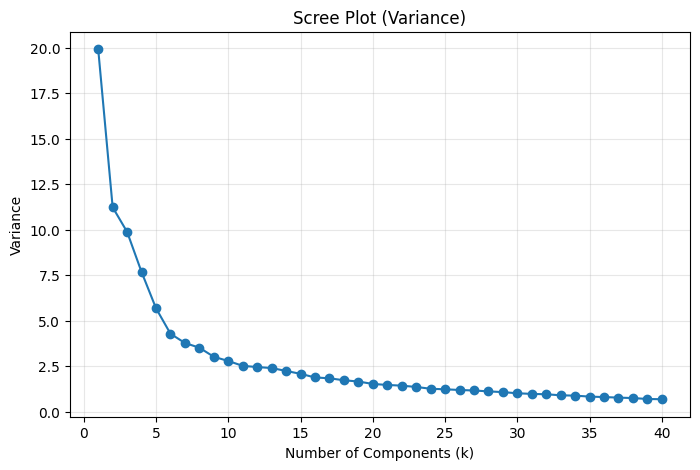

In [56]:
# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, 41), eigs, marker='o')
plt.title("Scree Plot (Variance)")
plt.xlabel("Number of Components (k)")
plt.ylabel("Variance")
plt.grid(True, alpha=0.3)
plt.show()

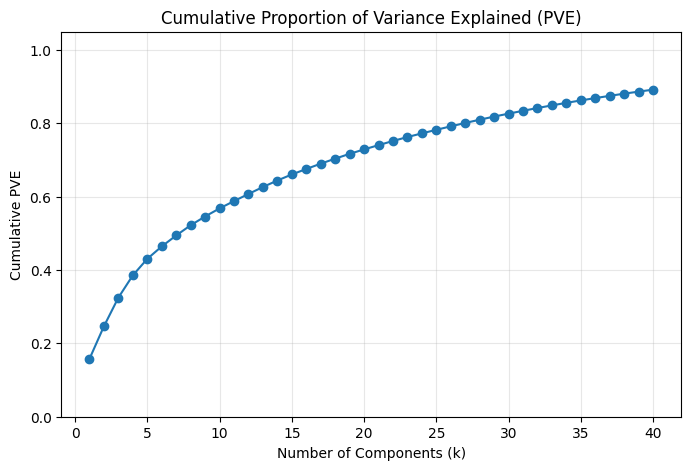

In [57]:
# Cumulative PVE
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, 41), cum_pve, marker='o')
plt.title("Cumulative Proportion of Variance Explained (PVE)")
plt.xlabel("Number of Components (k)")
plt.ylabel("Cumulative PVE")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

In [58]:
# Let's consider 6 components
components_6 = pca.components_[:6, :]
eigs_6 = eigs[:6]
# Loadings are component directions scaled by standard deviations
# Often used for interpretation
loadings = components_6.T * np.sqrt(eigs_6)

# Get variable names to help interpretation
varnames = list(complete.columns)

loadings_df = pd.DataFrame(loadings, index=varnames, columns=[f"PC{i+1}" for i in range(6)])

In [59]:
# Show top 10 by |loading| per component
top_rows = []
for i in range(6):
    col = loadings_df.iloc[:, i]
    top_vars = col.abs().sort_values(ascending=False).head(10).index.tolist()
    for rank, var in enumerate(top_vars, start=1):
        top_rows.append({"PC": f"PC{i+1}", "Rank": rank, "Variable": var, "Loading": loadings_df.loc[var, f"PC{i+1}"]})
top_df = pd.DataFrame(top_rows)
print(top_df)

     PC  Rank                                           Variable   Loading
0   PC1     1               All Employees:  Total nonfarm FD log  0.865900
1   PC1     2                     IP: Manufacturing (SIC) FD log  0.847910
2   PC1     3  IP: Final Products and Nonindustrial Supplies ...  0.829128
3   PC1     4  All Employees:  Service-Providing Industries F...  0.827164
4   PC1     5                                    IP Index FD log  0.812719
5   PC1     6            Capacity Utilization:  Manufacturing FD  0.800939
6   PC1     7                       IP: Durable Materials FD log  0.786867
7   PC1     8  All Employees:  Trade, Transportation & Utilit...  0.779325
8   PC1     9           IP: Final Products (Market Group) FD log  0.776860
9   PC1    10  All Employees:  Goods-Producing Industries FD log  0.755911
10  PC2     1                             CPI : All Items SD log  0.834764
11  PC2     2           CPI : All items less medical care SD log  0.833864
12  PC2     3            

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


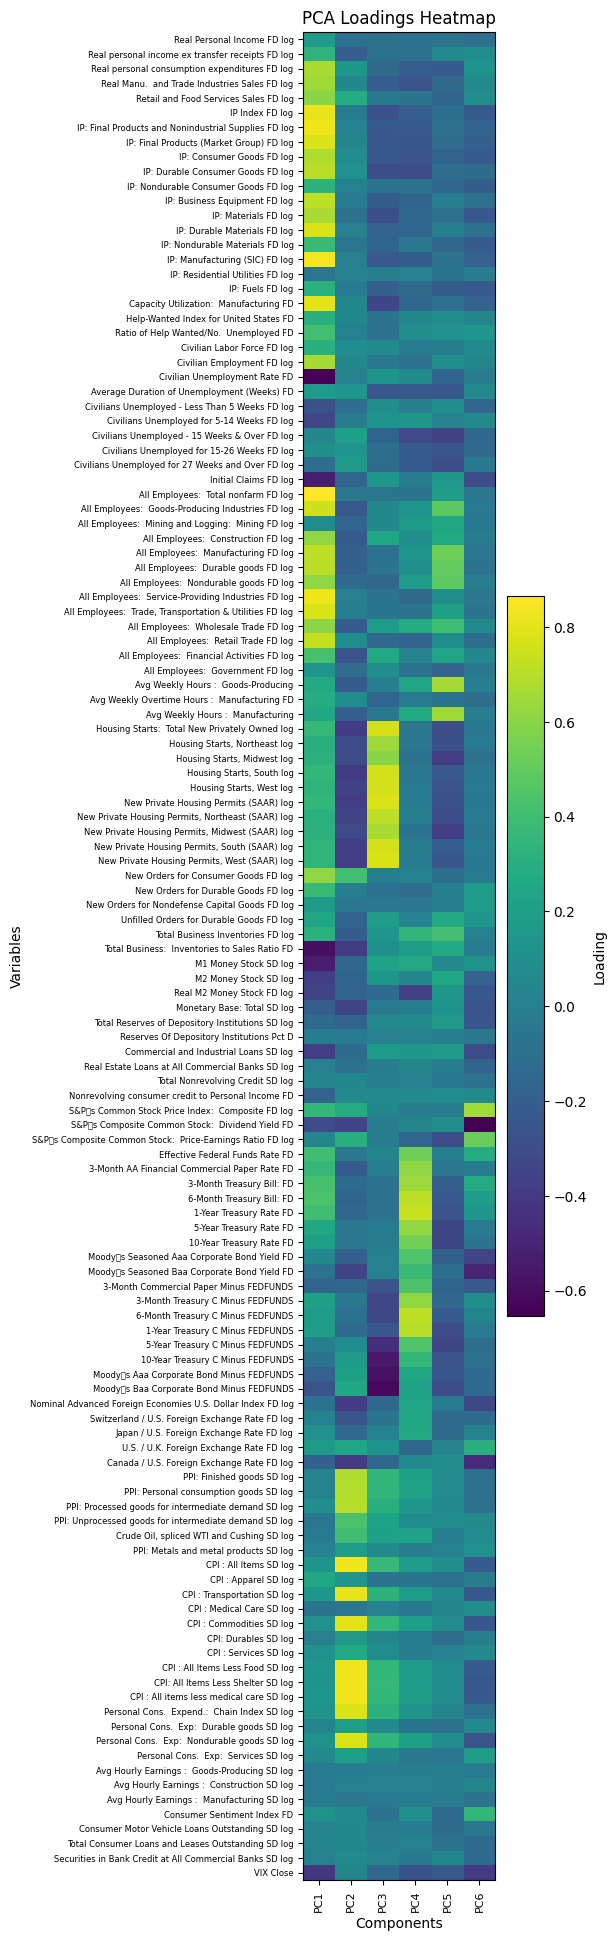

In [60]:
# Heatmap
n_features = loadings_df.shape[0]
height = min(2 + 0.2 * n_features, 24)
plt.figure(figsize=(1 + 0.35 * 6, height))
plt.imshow(loadings_df.values, aspect='auto', interpolation='nearest')
plt.colorbar(label="Loading")
plt.title("PCA Loadings Heatmap")
plt.yticks(ticks=np.arange(n_features), labels=varnames, fontsize=6 )
plt.xticks(ticks=np.arange(6), labels=[f"PC{i+1}" for i in range(6)], fontsize=8, rotation = 90 )
plt.xlabel("Components")
plt.ylabel("Variables")
plt.show()

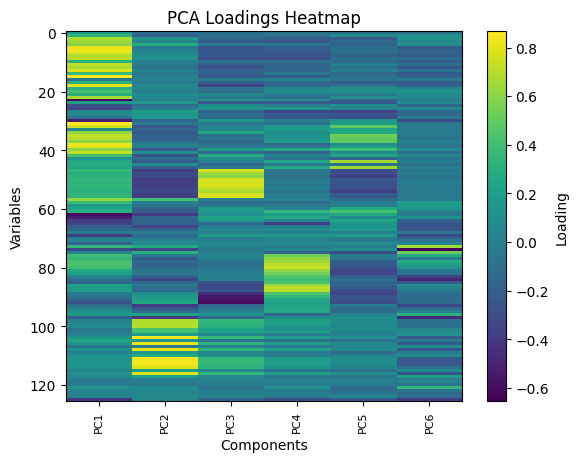

In [61]:
# Heatmap
n_features = loadings_df.shape[0]
plt.imshow(loadings_df.values, aspect='auto', interpolation='nearest')
plt.colorbar(label="Loading")
plt.title("PCA Loadings Heatmap")
plt.xticks(ticks=np.arange(6), labels=[f"PC{i+1}" for i in range(6)], fontsize=8, rotation = 90 )
plt.xlabel("Components")
plt.ylabel("Variables")
plt.show()

In [62]:
recessions = [
    ('2001-03', '2001-11'),
    ('2007-12', '2009-06'),
    ('2020-02', '2020-04')
]

# Convert to datetime
recessions = [(pd.to_datetime(s), pd.to_datetime(e)) for s, e in recessions]


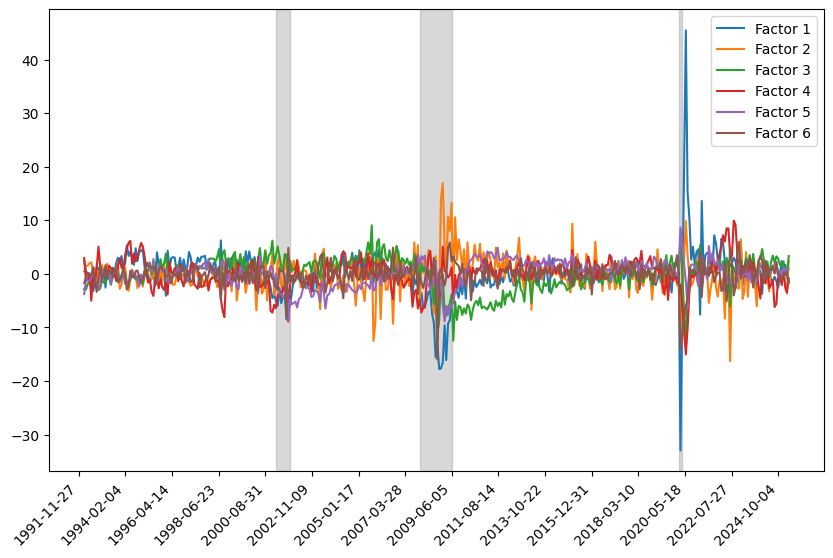

In [63]:
from matplotlib.ticker import MaxNLocator
date = pd.to_datetime(date)

# Time series plot of the extracted factors
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(6):
    ax.plot(date.loc[complete.index], x_pca[:, i], label=f'Factor {i+1}')
ax.legend()
ax.xaxis.set_major_locator(MaxNLocator(nbins=20))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

for start, end in recessions:
    ax.axvspan(start, end, color='gray', alpha=0.3)
plt.show()